# Week 1 — Python, NumPy, Pandas & Data Visualisation

**Course:** ML, Deep Learning & Computer Vision  
**Classes covered:** Class 1 (Python + NumPy) · Class 2 (Pandas + Visualisation)  
**Duration:** 2 × 2 hours  
**Format:** Theory + hands-on coding  

---

# 🔷 Class 1 — Python Essentials + NumPy

**Goal:** Get comfortable with Python's core constructs and learn why NumPy is the backbone of scientific computing in Python.

---
## Part 1 — Python Crash Course

If you already know another programming language, Python will feel refreshingly simple.  
We'll cover the essentials you'll use **every day** in ML work.

### 1.1 Variables & data types

Python is **dynamically typed** — you don't declare types. The interpreter figures it out.

| Type | Example | Use in ML |
|------|---------|----------|
| `int` | `42` | Counts, indices, epochs |
| `float` | `3.14` | Weights, losses, learning rates |
| `str` | `"hello"` | Labels, file paths |
| `bool` | `True` / `False` | Masks, conditions |
| `list` | `[1, 2, 3]` | Sequences of anything |
| `dict` | `{"lr": 0.01}` | Config, hyperparameters |
| `tuple` | `(224, 224)` | Image dimensions, shapes |

In [1]:
# Variables — no type declaration needed
learning_rate = 0.001        # float
epochs = 50                  # int
model_name = "ResNet-50"     # str
use_gpu = True               # bool

# Check types
print(type(learning_rate))   # <class 'float'>
print(type(epochs))          # <class 'int'>

# Type conversion
print(int(3.7))              # 3 (truncates, doesn't round)
print(float(5))              # 5.0
print(str(42))               # '42'

<class 'float'>
<class 'int'>
3
5.0
42


### 1.2 Lists — your go-to sequence

Lists are **ordered, mutable** collections. In ML, you'll use them for storing results, batching data, and more.

In [23]:
# Creating lists
accuracies = [0.72, 0.85, 0.91, 0.93, 0.95]
labels = ["cat", "dog", "bird"]

# Indexing (0-based) and slicing
print(accuracies[0])       # 0.72  (first element)
print(accuracies[-1])      # 0.95  (last element)
print(accuracies[1:3])     # [0.85, 0.91]  (index 1 and 2)
print(accuracies[::2])     # [0.72, 0.91, 0.95]  (every 2nd)
print()

# Modifying
accuracies.append(0.96)    # Add to end
accuracies.insert(0, 0.5)  # Insert at position 0
print(accuracies)
print()

# Useful operations
print(len(accuracies))     # Length
print(max(accuracies))     # Maximum value
print(sorted(accuracies))  # Sorted copy

0.72
0.95
[0.85, 0.91]
[0.72, 0.91, 0.95]

[0.5, 0.72, 0.85, 0.91, 0.93, 0.95, 0.96]

7
0.96
[0.5, 0.72, 0.85, 0.91, 0.93, 0.95, 0.96]


### 1.3 Dictionaries — key-value storage

Dicts map **keys to values**. In ML, they're used for hyperparameters, configs, label mappings, and results.

In [24]:
# Hyperparameter config — a very common ML pattern
config = {
    "learning_rate": 0.001,
    "batch_size": 32,
    "epochs": 100,
    "optimizer": "adam",
}

# Access
print(config["learning_rate"])           # 0.001
print(config.get("dropout", 0.5))        # 0.5 (default if key missing)
print()

# Modify / add
config["dropout"] = 0.3
config["epochs"] = 200

# Iterate
for key, value in config.items():
    print(f"  {key}: {value}")

0.001
0.5

  learning_rate: 0.001
  batch_size: 32
  epochs: 200
  optimizer: adam
  dropout: 0.3


### 1.4 Control flow

Python uses **indentation** (not braces) to define blocks. Typically 4 spaces.

In [4]:
# If / elif / else
accuracy = 0.92

if accuracy > 0.95:
    print("Excellent model!")
elif accuracy > 0.85:
    print("Good model, might improve with tuning")
else:
    print("Needs more work")

# For loops
losses = [2.3, 1.8, 1.2, 0.8, 0.5]
for epoch, loss in enumerate(losses):
    print(f"Epoch {epoch + 1}: loss = {loss:.2f}")

# While loop
loss = 10.0
step = 0
while loss > 1.0:
    loss *= 0.7  # simulate decreasing loss
    step += 1
print(f"Converged after {step} steps, final loss = {loss:.4f}")

Good model, might improve with tuning
Epoch 1: loss = 2.30
Epoch 2: loss = 1.80
Epoch 3: loss = 1.20
Epoch 4: loss = 0.80
Epoch 5: loss = 0.50
Converged after 7 steps, final loss = 0.8235


### 1.5 Functions

Functions let you **reuse** code. In ML, you'll write functions for data loading, preprocessing, training loops, and evaluation.

In [10]:
# Basic function
def compute_accuracy(correct, total):
    """Compute accuracy as a percentage."""
    return (correct / total) * 100

print(compute_accuracy(47, 50))  # 94.0


# Default arguments — very common in ML APIs
def train(model_name, lr=0.001, epochs=10, verbose=True):
    """Simulate a training run."""
    if verbose:
        print(f"Training {model_name} | lr={lr}, epochs={epochs}")
    return {"model": model_name, "final_loss": 0.05}  # return a dict

result = train("ResNet", lr=0.01, epochs=50)
print(result)

94.0
Training ResNet | lr=0.01, epochs=50
{'model': 'ResNet', 'final_loss': 0.05}


### 1.6 List comprehensions

A Pythonic way to create lists in one line. You'll see these **everywhere** in ML code.

In [11]:
# Standard loop vs comprehension
# Loop version:
squares = []
for i in range(10):
    squares.append(i ** 2)

# Comprehension version (same result, cleaner):
squares = [i ** 2 for i in range(10)]
print(squares)

# With condition — filter even squares
even_squares = [i ** 2 for i in range(10) if i % 2 == 0]
print(even_squares)

# Practical ML example: extract image filenames
files = ["img01.jpg", "notes.txt", "img02.png", "data.csv", "img03.jpg"]
images = [f for f in files if f.endswith((".jpg", ".png"))]
print(images)

# Dict comprehension
labels = ["cat", "dog", "bird"]
label_to_id = {label: idx for idx, label in enumerate(labels)}
print(label_to_id)  # {'cat': 0, 'dog': 1, 'bird': 2}

[0, 1, 4, 9, 16, 25, 36, 49, 64, 81]
[0, 4, 16, 36, 64]
['img01.jpg', 'img02.png', 'img03.jpg']
{'cat': 0, 'dog': 1, 'bird': 2}


### 1.7 Classes (OOP basics)

In deep learning (especially PyTorch), **every model is a class**. Understanding classes is essential.

In [12]:
class SimpleModel:
    """A toy model class to illustrate OOP patterns used in PyTorch."""

    def __init__(self, name, input_size, output_size):
        self.name = name
        self.input_size = input_size
        self.output_size = output_size
        self.is_trained = False

    def train(self, data):
        print(f"Training {self.name} on {len(data)} samples...")
        self.is_trained = True

    def predict(self, x):
        if not self.is_trained:
            raise RuntimeError("Model not trained yet!")
        return [0] * len(x)  # dummy prediction

    def __repr__(self):
        return f"SimpleModel('{self.name}', {self.input_size} → {self.output_size})"


# Usage
model = SimpleModel("MyNet", input_size=784, output_size=10)
print(model)  # calls __repr__

model.train(data=[1, 2, 3, 4, 5])
preds = model.predict([10, 20, 30])
print(f"Predictions: {preds}")

SimpleModel('MyNet', 784 → 10)
Training MyNet on 5 samples...
Predictions: [0, 0, 0]


---
## Part 2 — NumPy: The Engine Under the Hood

**Why NumPy?** Every ML/DL framework (Scikit-learn, PyTorch, TensorFlow) is built on top of array operations.  
NumPy gives you:
- **Speed** — operations run in optimised C code, not slow Python loops
- **Broadcasting** — automatic shape matching for element-wise ops
- **Ecosystem** — the lingua franca of scientific Python

> **Key insight:** If you're writing a `for` loop over numbers in Python, you're probably doing it wrong. NumPy lets you express the same thing as a single array operation, often 50–100× faster.

In [13]:
import numpy as np

# Check version
print(f"NumPy version: {np.__version__}")

NumPy version: 2.0.2


### 2.1 Creating arrays

A NumPy array (`ndarray`) is a grid of values, all of the **same type**. This uniformity is what makes it fast.

In [16]:
# From a Python list
a = np.array([1, 2, 3, 4, 5])
print(a)            # [1 2 3 4 5]
print(a.shape)      # (5,)  — 1D array with 5 elements
print(a.dtype)      # int64
print()

# 2D array (matrix) — rows and columns
m = np.array([[1, 2, 3],
              [4, 5, 6]])
print(m.shape)      # (2, 3) — 2 rows, 3 columns
print()

# Common constructors
print(np.zeros((3, 4)))        # 3×4 matrix of zeros
print(np.ones((2, 2)))         # 2×2 matrix of ones
print(np.eye(3))               # 3×3 identity matrix
print(np.arange(0, 10, 2))    # [0 2 4 6 8]  — like range()
print(np.linspace(0, 1, 5))   # [0. 0.25 0.5 0.75 1.] — 5 evenly spaced
print()

# Random arrays (you'll use these A LOT)
np.random.seed(42)  # for reproducibility
print(np.random.randn(3, 3))   # 3×3 from standard normal
print(np.random.rand(2, 4))    # 2×4 uniform [0, 1)
print(np.random.randint(0, 10, size=(2, 3)))  # random ints

[1 2 3 4 5]
(5,)
int64

(2, 3)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]
[[1. 1.]
 [1. 1.]]
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
[0 2 4 6 8]
[0.   0.25 0.5  0.75 1.  ]

[[ 0.49671415 -0.1382643   0.64768854]
 [ 1.52302986 -0.23415337 -0.23413696]
 [ 1.57921282  0.76743473 -0.46947439]]
[[0.18182497 0.18340451 0.30424224 0.52475643]
 [0.43194502 0.29122914 0.61185289 0.13949386]]
[[2 6 3]
 [8 2 4]]


### 2.2 Indexing, slicing & boolean masking

Selecting subsets of arrays is the most common operation in data work.

In [18]:
a = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90])

# Basic indexing
print(a[0])       # 10
print(a[-1])      # 90
print(a[2:5])     # [30 40 50]  — start:stop (exclusive)
print(a[::3])     # [10 40 70]  — every 3rd element
print()

# 2D indexing
m = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])
print(m[0, 2])     # 3     — row 0, col 2
print(m[1, :])     # [4 5 6] — entire row 1
print(m[:, 0])     # [1 4 7] — entire column 0
print(m[0:2, 1:3]) # [[2,3],[5,6]] — submatrix
print()

# Boolean masking — incredibly useful for filtering data
scores = np.array([0.3, 0.7, 0.9, 0.2, 0.85, 0.6])
mask = scores > 0.5
print(mask)                    # [False True True False True True]
print(scores[mask])            # [0.7  0.9  0.85 0.6] — only high scores
print(np.where(scores > 0.5)) # indices where condition is True

10
90
[30 40 50]
[10 40 70]

3
[4 5 6]
[1 4 7]
[[2 3]
 [5 6]]

[False  True  True False  True  True]
[0.7  0.9  0.85 0.6 ]
(array([1, 2, 4, 5]),)


### 2.3 Vectorised operations & broadcasting

**Vectorisation** = applying an operation to an entire array at once, without a Python loop.  
**Broadcasting** = NumPy's rules for handling operations between arrays of different shapes.

**Broadcasting rules (simplified):**
1. If arrays have different numbers of dimensions, pad the smaller shape with 1s on the left
2. Arrays with size 1 along a dimension are stretched to match the other array
3. If sizes disagree and neither is 1 → error

In [19]:
a = np.array([1, 2, 3, 4, 5])

# Element-wise operations — no loop needed
print(a + 10)        # [11 12 13 14 15]  — scalar broadcast
print(a * 2)         # [ 2  4  6  8 10]
print(a ** 2)        # [ 1  4  9 16 25]
print(np.sqrt(a))    # [1.   1.41 1.73 2.   2.24]
print()

# Array + Array (same shape)
b = np.array([10, 20, 30, 40, 50])
print(a + b)         # [11 22 33 44 55]
print()

# Broadcasting: matrix + vector
m = np.array([[1, 2, 3],
              [4, 5, 6]])  # shape (2, 3)
v = np.array([10, 20, 30])         # shape (3,)
print(m + v)
# [[11, 22, 33],
#  [14, 25, 36]]   — v is broadcast across each row

[11 12 13 14 15]
[ 2  4  6  8 10]
[ 1  4  9 16 25]
[1.         1.41421356 1.73205081 2.         2.23606798]

[11 22 33 44 55]

[[11 22 33]
 [14 25 36]]


### 2.4 Aggregations, reshaping & stacking

In [20]:
data = np.random.randn(4, 3)  # 4 samples, 3 features
print("Data:\n", data)
print()

# Aggregations
print("\nMean (all):", data.mean())
print("Mean per column:", data.mean(axis=0))   # shape (3,)
print("Mean per row:",    data.mean(axis=1))   # shape (4,)
print("Std per column:",  data.std(axis=0))
print("Min:", data.min(), "Max:", data.max())
print("Argmax (flat):",   data.argmax())       # index of max in flattened array
print()

# Reshaping
a = np.arange(12)
print("\nOriginal:", a.shape)       # (12,)
print(a.reshape(3, 4))              # 3 rows × 4 cols
print(a.reshape(2, 2, 3))           # 2 × 2 × 3  (like a tiny black and white image batch)
print(a.reshape(3, -1))             # -1 = infer → (3, 4)
print()

# Stacking
x = np.array([1, 2, 3])
y = np.array([4, 5, 6])
print("\nvstack:\n", np.vstack([x, y]))  # (2, 3)
print("hstack:", np.hstack([x, y]))       # (6,)

Data:
 [[ 0.54256004 -1.15099358  0.37569802]
 [-0.60063869 -0.29169375 -0.60170661]
 [ 1.85227818 -0.01349722 -1.05771093]
 [ 0.82254491 -1.22084365  0.2088636 ]]


Mean (all): -0.09459497329000993
Mean per column: [ 0.65418611 -0.66925705 -0.26871398]
Mean per row: [-0.07757851 -0.49801302  0.26035668 -0.06314505]
Std per column: [0.87332911 0.52651991 0.58667441]
Min: -1.2208436499710222 Max: 1.8522781845089378
Argmax (flat): 6


Original: (12,)
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
[[[ 0  1  2]
  [ 3  4  5]]

 [[ 6  7  8]
  [ 9 10 11]]]
[[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]


vstack:
 [[1 2 3]
 [4 5 6]]
hstack: [1 2 3 4 5 6]


### 2.5 Dot product & matrix multiplication

Matrix multiplication is the **core operation** of neural networks. Every layer computes `output = input @ weights + bias`.

In [21]:
# Dot product of two vectors
a = np.array([1, 2, 3])
b = np.array([4, 5, 6])
print("Dot product:", np.dot(a, b))  # 1*4 + 2*5 + 3*6 = 32
print()

# Matrix multiplication
X = np.array([[1, 2],
              [3, 4],
              [5, 6]])   # shape (3, 2) — 3 samples, 2 features

W = np.array([[0.5, -0.1, 0.3],
              [0.2,  0.7, -0.4]])  # shape (2, 3) — weights

output = X @ W  # (3, 2) @ (2, 3) → (3, 3)
print("X @ W =\n", output)
print("Shape:", output.shape)  # (3, 3)
print()

# This is literally what a neural network layer does:
bias = np.array([0.1, 0.1, 0.1])
layer_output = X @ W + bias
print("\nLayer output (X @ W + b):\n", layer_output)

Dot product: 32

X @ W =
 [[ 0.9  1.3 -0.5]
 [ 2.3  2.5 -0.7]
 [ 3.7  3.7 -0.9]]
Shape: (3, 3)


Layer output (X @ W + b):
 [[ 1.   1.4 -0.4]
 [ 2.4  2.6 -0.6]
 [ 3.8  3.8 -0.8]]


### 2.6 🏎️ Speed comparison: loops vs vectorisation

This is **the** reason NumPy exists. Let's see how much faster it is.

In [22]:
import time

size = 1_000_000
a_list = list(range(size))
a_np = np.arange(size)

# Python loop
start = time.time()
result_loop = [x ** 2 for x in a_list]
loop_time = time.time() - start

# NumPy vectorised
start = time.time()
result_np = a_np ** 2
np_time = time.time() - start

print(f"Python loop:    {loop_time:.4f} sec")
print(f"NumPy vectorised: {np_time:.4f} sec")
print(f"Speedup:        {loop_time / np_time:.0f}×")

Python loop:    0.0423 sec
NumPy vectorised: 0.0021 sec
Speedup:        20×


---
## ✏️ Exercises — Class 1

Complete these to solidify your understanding. Solutions are at the bottom.

**Exercise 1:** Write a function `relu(x)` that takes a NumPy array and returns `max(0, x)` element-wise. This is the most common activation function in deep learning.

In [25]:
# Your code here
def relu(x):
    pass

# Test
# test_input = np.array([-3, -1, 0, 2, 5])
# print(relu(test_input))  # expected: [0 0 0 2 5]

**Exercise 2:** Given a matrix of exam scores (students × subjects), compute:  
a) Each student's average score (mean across columns)  
b) The highest score in each subject (max across rows)  
c) Which student had the highest overall average?

In [26]:
np.random.seed(0)
scores = np.random.randint(50, 100, size=(6, 4))  # 6 students, 4 subjects
print("Scores:\n", scores)

# a) Student averages

# b) Highest per subject

# c) Best student index


Scores:
 [[94 97 50 53]
 [53 89 59 69]
 [71 86 73 56]
 [74 74 62 51]
 [88 89 73 96]
 [74 67 87 75]]


**Exercise 3:** Normalise each column of a matrix to have mean=0 and std=1 (z-score normalisation). This is called **standardisation** and is used before training most ML models.

Formula: `z = (x - mean) / std` applied column-wise.

In [27]:
np.random.seed(42)
data = np.random.randn(5, 3) * 10 + 50  # 5 samples, 3 features, centred around 50
print("Before:\n", data)
print("Column means:", data.mean(axis=0))
print("Column stds: ", data.std(axis=0))

# Standardise here

# Verify: column means ≈ 0, stds ≈ 1


Before:
 [[54.96714153 48.61735699 56.47688538]
 [65.23029856 47.65846625 47.65863043]
 [65.79212816 57.67434729 45.30525614]
 [55.42560044 45.36582307 45.34270246]
 [52.41962272 30.86719755 32.75082167]]
Column means: [58.76695828 46.03663823 45.50685922]
Column stds:  [5.60392234 8.66358622 7.58624648]


**Exercise 4:** Implement matrix multiplication from scratch using Python loops, then verify your result matches `np.dot()`. Compare the speed for a 100×100 matrix.

In [28]:
def matmul_loops(A, B):
    """Matrix multiplication using three nested loops."""
    pass  # Your code here

# Test with small matrices first
# A = np.array([[1, 2], [3, 4]])
# B = np.array([[5, 6], [7, 8]])
# print(matmul_loops(A, B))
# print(A @ B)  # should match

---
---
# 🔷 Class 2 — Pandas + Data Visualisation

**Goal:** Load, clean, explore, and visualise real-world data — the first 80% of any ML project.

---
## Part 3 — Pandas: Working With Tabular Data

**Pandas** gives you `DataFrame` — a table with labelled rows and columns.  
Think of it as a programmable spreadsheet. In ML, you'll use it for:
- Loading datasets (CSV, Excel, SQL)
- Cleaning messy data
- Exploratory data analysis (EDA)
- Feature engineering

In [29]:
import pandas as pd

print(f"Pandas version: {pd.__version__}")

Pandas version: 2.2.2


### 3.1 Series & DataFrames

- **Series** = a single column (1D labelled array)
- **DataFrame** = a table (2D, multiple Series sharing an index)

In [30]:
# Creating a DataFrame from a dictionary
data = {
    "model": ["Linear Reg", "Random Forest", "SVM", "Neural Net", "XGBoost"],
    "accuracy": [0.72, 0.89, 0.85, 0.93, 0.91],
    "train_time_sec": [0.5, 3.2, 12.0, 45.0, 8.5],
    "n_params": [10, 500, 50, 10000, 300],
}

df = pd.DataFrame(data)
print(df)
print("\nShape:", df.shape)       # (5, 4)
print("Columns:", list(df.columns))
print("dtypes:\n", df.dtypes)

           model  accuracy  train_time_sec  n_params
0     Linear Reg      0.72             0.5        10
1  Random Forest      0.89             3.2       500
2            SVM      0.85            12.0        50
3     Neural Net      0.93            45.0     10000
4        XGBoost      0.91             8.5       300

Shape: (5, 4)
Columns: ['model', 'accuracy', 'train_time_sec', 'n_params']
dtypes:
 model              object
accuracy          float64
train_time_sec    float64
n_params            int64
dtype: object


### 3.2 Selecting, filtering & sorting

In [32]:
# Select a single column (returns a Series)
print(df["accuracy"])
print()

# Select multiple columns
print(df[["model", "accuracy"]])
print()

# Filter rows with a condition
good_models = df[df["accuracy"] > 0.85]
print("\nModels with accuracy > 85%:")
print(good_models)
print()

# Multiple conditions (use & for AND, | for OR)
fast_and_good = df[(df["accuracy"] > 0.85) & (df["train_time_sec"] < 10)]
print("\nFast AND accurate:")
print(fast_and_good)
print()

# Sort
print("\nSorted by accuracy (descending):")
print(df.sort_values("accuracy", ascending=False))

0    0.72
1    0.89
2    0.85
3    0.93
4    0.91
Name: accuracy, dtype: float64

           model  accuracy
0     Linear Reg      0.72
1  Random Forest      0.89
2            SVM      0.85
3     Neural Net      0.93
4        XGBoost      0.91


Models with accuracy > 85%:
           model  accuracy  train_time_sec  n_params
1  Random Forest      0.89             3.2       500
3     Neural Net      0.93            45.0     10000
4        XGBoost      0.91             8.5       300


Fast AND accurate:
           model  accuracy  train_time_sec  n_params
1  Random Forest      0.89             3.2       500
4        XGBoost      0.91             8.5       300


Sorted by accuracy (descending):
           model  accuracy  train_time_sec  n_params
3     Neural Net      0.93            45.0     10000
4        XGBoost      0.91             8.5       300
1  Random Forest      0.89             3.2       500
2            SVM      0.85            12.0        50
0     Linear Reg      0.72        

### 3.3 Working with real data — Titanic dataset

Let's create a small synthetic version of the Titanic dataset to practise data cleaning.  
(In a real project, you'd load this from a CSV file.)

In [33]:
# Synthetic Titanic-like data
np.random.seed(42)
n = 200

titanic = pd.DataFrame({
    "survived": np.random.choice([0, 1], n, p=[0.6, 0.4]),
    "pclass": np.random.choice([1, 2, 3], n, p=[0.2, 0.3, 0.5]),
    "sex": np.random.choice(["male", "female"], n),
    "age": np.where(np.random.rand(n) < 0.15, np.nan,
                     np.random.normal(30, 12, n).clip(1, 80).round(1)),
    "fare": np.random.exponential(30, n).round(2),
    "embarked": np.random.choice(["S", "C", "Q", np.nan], n, p=[0.6, 0.2, 0.15, 0.05]),
})

print(titanic.head(10))

   survived  pclass     sex   age   fare embarked
0         0       3    male  22.2  31.62        C
1         1       1  female  30.6  53.11        S
2         1       1    male  19.7   6.94        S
3         0       3    male  25.4   0.33        Q
4         0       3  female  42.1   4.42        C
5         0       1  female  23.1  69.08        C
6         0       1  female  40.0  62.12        Q
7         1       3    male  16.4  27.30        Q
8         1       1  female  36.4  27.53        C
9         1       1    male  47.3  32.81        Q


In [34]:
# Quick overview
print(titanic.info())    # column types, non-null counts
print("\n")
print(titanic.describe())  # statistics for numeric columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  200 non-null    int64  
 1   pclass    200 non-null    int64  
 2   sex       200 non-null    object 
 3   age       170 non-null    float64
 4   fare      200 non-null    float64
 5   embarked  200 non-null    object 
dtypes: float64(2), int64(2), object(2)
memory usage: 9.5+ KB
None


         survived      pclass         age        fare
count  200.000000  200.000000  170.000000  200.000000
mean     0.390000    2.325000   29.753529   32.141750
std      0.488974    0.814057   12.009824   32.112036
min      0.000000    1.000000    1.000000    0.330000
25%      0.000000    2.000000   23.175000    8.130000
50%      0.000000    3.000000   29.600000   22.265000
75%      1.000000    3.000000   37.550000   45.602500
max      1.000000    3.000000   60.900000  185.470000


### 3.4 Handling missing data

Real datasets **always** have missing values. You need to detect and handle them before training.

In [35]:
# Count missing values per column
print("Missing values:")
print(titanic.isnull().sum())
print(f"\nTotal cells: {titanic.size}")
print(f"Missing: {titanic.isnull().sum().sum()} ({titanic.isnull().sum().sum()/titanic.size*100:.1f}%)")

# Strategy 1: Fill with median (good for numeric columns with outliers)
titanic["age"] = titanic["age"].fillna(titanic["age"].median())

# Strategy 2: Fill with mode (good for categorical columns)
titanic["embarked"] = titanic["embarked"].fillna(titanic["embarked"].mode()[0])

# Verify: no more nulls
print("\nAfter cleaning:")
print(titanic.isnull().sum())

Missing values:
survived     0
pclass       0
sex          0
age         30
fare         0
embarked     0
dtype: int64

Total cells: 1200
Missing: 30 (2.5%)

After cleaning:
survived    0
pclass      0
sex         0
age         0
fare        0
embarked    0
dtype: int64


### 3.5 Groupby & aggregation

Split the data into groups → apply a function → combine results. This is your main tool for EDA.

In [36]:
# Survival rate by sex
print(titanic.groupby("sex")["survived"].mean())

# Survival rate by class
print("\n", titanic.groupby("pclass")["survived"].mean())

# Multiple aggregations
summary = titanic.groupby(["pclass", "sex"]).agg(
    survival_rate=("survived", "mean"),
    avg_age=("age", "mean"),
    avg_fare=("fare", "mean"),
    count=("survived", "count"),
).round(2)
print("\nDetailed summary:")
print(summary)

sex
female    0.416667
male      0.365385
Name: survived, dtype: float64

 pclass
1    0.363636
2    0.404255
3    0.394495
Name: survived, dtype: float64

Detailed summary:
               survival_rate  avg_age  avg_fare  count
pclass sex                                            
1      female           0.45    25.85     31.45     22
       male             0.27    29.02     39.96     22
2      female           0.50    30.93     44.53     26
       male             0.29    31.29     27.00     21
3      female           0.35    30.06     25.51     48
       male             0.43    30.08     31.28     61


### 3.6 Feature engineering preview

Creating new columns from existing ones. This is where domain knowledge meets data.

In [37]:
# Create new features
titanic["is_child"] = (titanic["age"] < 18).astype(int)
titanic["fare_per_class"] = titanic["fare"] / titanic["pclass"]

# One-hot encoding for categorical variables
titanic_encoded = pd.get_dummies(titanic, columns=["sex", "embarked"], drop_first=True)
print(titanic_encoded.head())
print("\nColumns after encoding:", list(titanic_encoded.columns))

   survived  pclass   age   fare  is_child  fare_per_class  sex_male  \
0         0       3  22.2  31.62         0       10.540000      True   
1         1       1  30.6  53.11         0       53.110000     False   
2         1       1  19.7   6.94         0        6.940000      True   
3         0       3  25.4   0.33         0        0.110000      True   
4         0       3  42.1   4.42         0        1.473333     False   

   embarked_Q  embarked_S  embarked_nan  
0       False       False         False  
1       False        True         False  
2       False        True         False  
3        True       False         False  
4       False       False         False  

Columns after encoding: ['survived', 'pclass', 'age', 'fare', 'is_child', 'fare_per_class', 'sex_male', 'embarked_Q', 'embarked_S', 'embarked_nan']


---
## Part 4 — Data Visualisation

Visualisation is how you **understand** your data before building models.  
We'll use **Matplotlib** (low-level, full control) and **Seaborn** (high-level, prettier defaults).

> **Rule of thumb:** If you can't plot it, you don't understand it.

In [39]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (10, 4)
matplotlib.rcParams['figure.dpi'] = 100

# If running in Jupyter, this makes plots show inline:
%matplotlib inline

### 4.1 Matplotlib fundamentals

Matplotlib has two interfaces:
- **pyplot** (quick one-offs): `plt.plot(x, y)` → `plt.show()`
- **object-oriented** (recommended for anything serious): `fig, ax = plt.subplots()`

We'll use the OO interface from the start — it's cleaner and what you'll see in ML code.

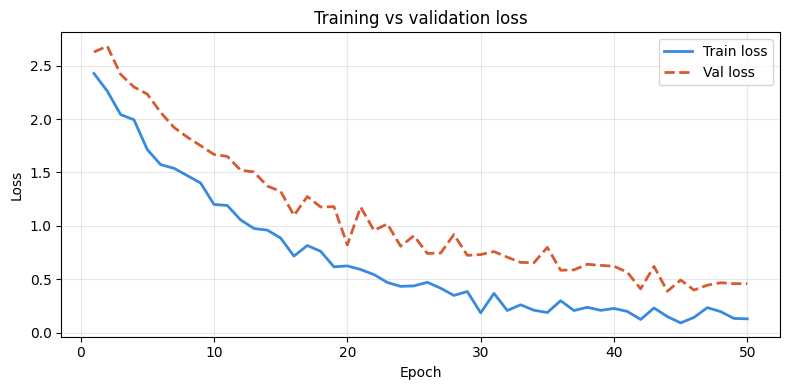

In [40]:
# Simulate training loss over epochs
epochs = np.arange(1, 51)
train_loss = 2.5 * np.exp(-0.08 * epochs) + 0.1 + np.random.randn(50) * 0.05
val_loss = 2.5 * np.exp(-0.06 * epochs) + 0.3 + np.random.randn(50) * 0.08

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(epochs, train_loss, label="Train loss", color="#378ADD", linewidth=2)
ax.plot(epochs, val_loss, label="Val loss", color="#D85A30", linewidth=2, linestyle="--")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Training vs validation loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 4.2 Essential chart types for ML

| Chart | When to use |
|-------|------------|
| **Line** | Loss curves, metrics over time |
| **Bar** | Comparing categories, feature importance |
| **Histogram** | Distribution of a variable |
| **Scatter** | Relationship between two variables |
| **Heatmap** | Correlation matrices, confusion matrices |
| **Box plot** | Distribution comparison across groups |

/tmp/ipykernel_1688/1678460678.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1, 0].boxplot(class_data, labels=["1st", "2nd", "3rd"], patch_artist=True)


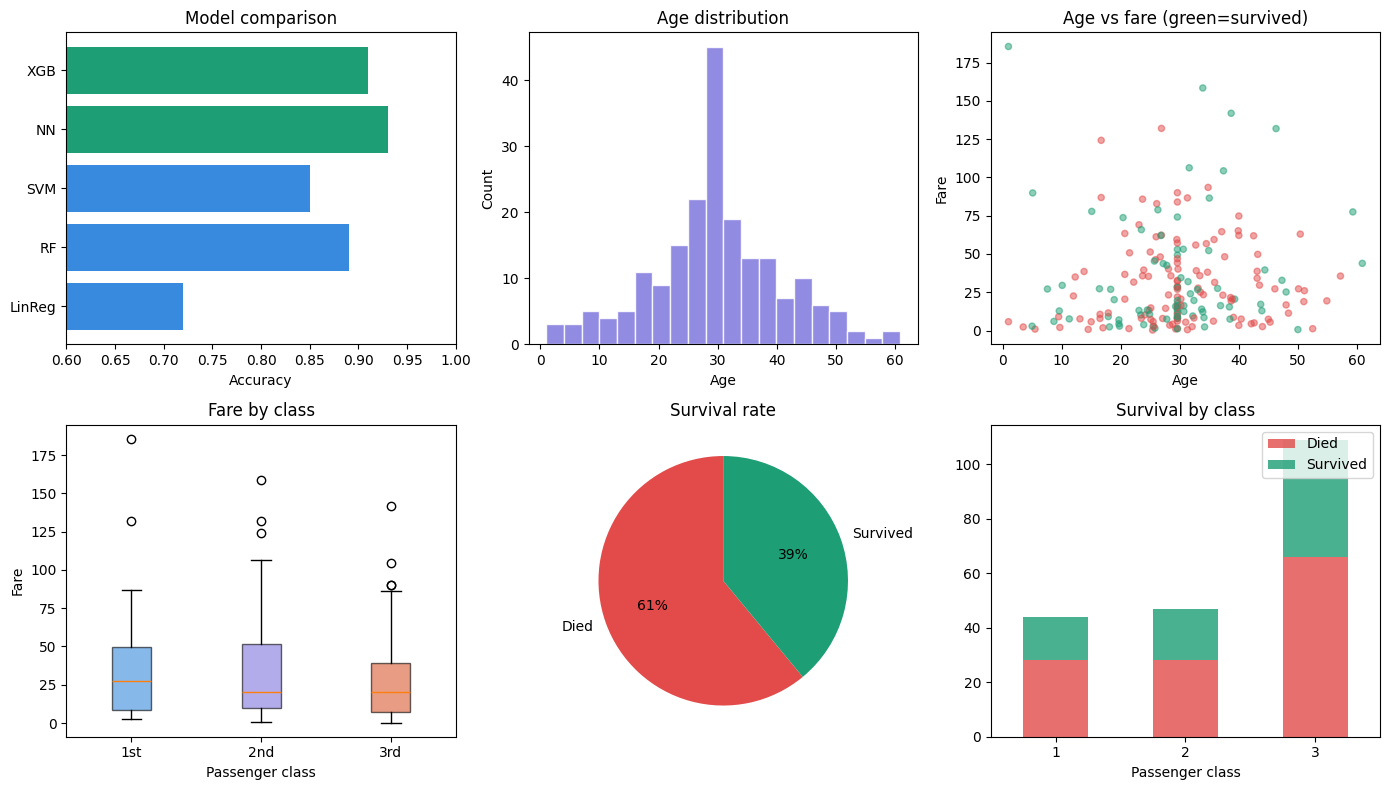

In [44]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

# 1. Bar chart — model comparison
models = ["LinReg", "RF", "SVM", "NN", "XGB"]
accs = [0.72, 0.89, 0.85, 0.93, 0.91]
colors = ["#378ADD" if a < 0.9 else "#1D9E75" for a in accs]
axes[0, 0].barh(models, accs, color=colors)
axes[0, 0].set_xlabel("Accuracy")
axes[0, 0].set_title("Model comparison")
axes[0, 0].set_xlim(0.6, 1.0)

# 2. Histogram — age distribution
axes[0, 1].hist(titanic["age"], bins=20, color="#7F77DD", edgecolor="white", alpha=0.85)
axes[0, 1].set_xlabel("Age")
axes[0, 1].set_ylabel("Count")
axes[0, 1].set_title("Age distribution")

# 3. Scatter — age vs fare
survived_colors = titanic["survived"].map({0: "#E24B4A", 1: "#1D9E75"})
axes[0, 2].scatter(titanic["age"], titanic["fare"], c=survived_colors, alpha=0.5, s=20)
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Fare")
axes[0, 2].set_title("Age vs fare (green=survived)")

# 4. Box plot — fare by class
class_data = [titanic[titanic["pclass"] == c]["fare"] for c in [1, 2, 3]]
bp = axes[1, 0].boxplot(class_data, labels=["1st", "2nd", "3rd"], patch_artist=True)
for patch, color in zip(bp["boxes"], ["#378ADD", "#7F77DD", "#D85A30"]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[1, 0].set_xlabel("Passenger class")
axes[1, 0].set_ylabel("Fare")
axes[1, 0].set_title("Fare by class")

# 5. Pie chart — survival rate
survived_counts = titanic["survived"].value_counts()
axes[1, 1].pie(survived_counts, labels=["Died", "Survived"],
               colors=["#E24B4A", "#1D9E75"], autopct="%1.0f%%", startangle=90)
axes[1, 1].set_title("Survival rate")

# 6. Stacked bar — survival by class
surv_by_class = titanic.groupby("pclass")["survived"].value_counts().unstack(fill_value=0)
surv_by_class.plot(kind="bar", stacked=True, ax=axes[1, 2],
                   color=["#E24B4A", "#1D9E75"], alpha=0.8)
axes[1, 2].set_xlabel("Passenger class")
axes[1, 2].set_title("Survival by class")
axes[1, 2].legend(["Died", "Survived"], loc="upper right")
axes[1, 2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 4.3 Seaborn — statistical plots with less code

Seaborn builds on Matplotlib and adds beautiful defaults + powerful statistical plots.

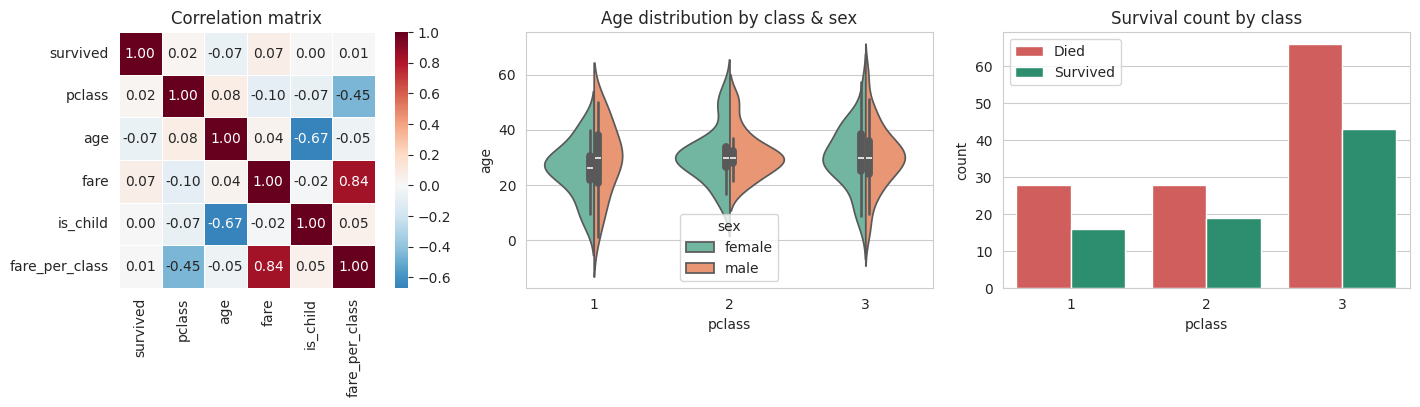

In [45]:
import seaborn as sns
sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Correlation heatmap — essential for EDA
numeric_cols = titanic.select_dtypes(include=[np.number])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title("Correlation matrix")

# 2. Violin plot — distribution by group
sns.violinplot(data=titanic, x="pclass", y="age", hue="sex",
               split=True, ax=axes[1], palette="Set2")
axes[1].set_title("Age distribution by class & sex")

# 3. Count plot
sns.countplot(data=titanic, x="pclass", hue="survived",
              palette=["#E24B4A", "#1D9E75"], ax=axes[2])
axes[2].set_title("Survival count by class")
axes[2].legend(["Died", "Survived"])

plt.tight_layout()
plt.show()

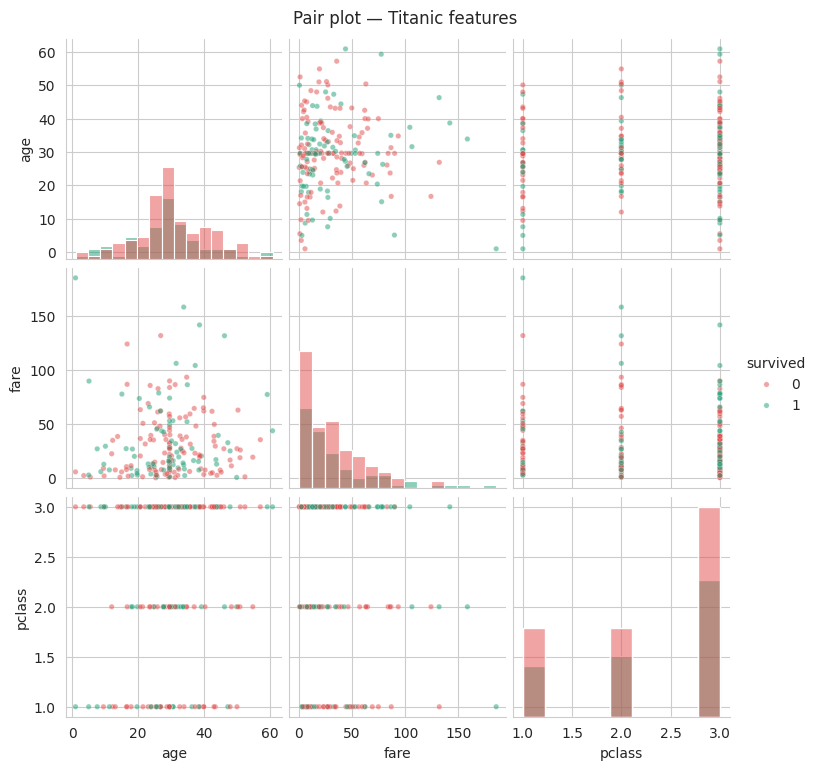

In [46]:
# Pair plot — all pairwise relationships at once
# This is often the FIRST thing you do in EDA
g = sns.pairplot(titanic[["age", "fare", "pclass", "survived"]],
                 hue="survived", palette=["#E24B4A", "#1D9E75"],
                 diag_kind="hist", plot_kws={"alpha": 0.5, "s": 15})
g.figure.suptitle("Pair plot — Titanic features", y=1.02)
plt.show()

---
## ✏️ Exercises — Class 2

**Exercise 5:** Using the Titanic DataFrame, answer these questions with Pandas:

a) What was the average fare for each combination of class and sex?  
b) What percentage of children (age < 18) survived vs adults?  
c) Which embarkation port had the highest survival rate?

In [ ]:
# a) Average fare by class and sex

# b) Child vs adult survival rate

# c) Survival rate by embarkation port


**Exercise 6:** Create a **2×3 subplot dashboard** of the Titanic data containing:

1. Histogram of fares (with 25 bins)
2. Bar chart of survival rate by class
3. Scatter plot of age vs fare, coloured by survival
4. Box plot of age by survival status
5. Heatmap of correlation matrix
6. A chart of your choice

Make it look polished: add titles, labels, a main title, and use `plt.tight_layout()`.

In [ ]:
# Build your dashboard here
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Titanic EDA Dashboard", fontsize=16, fontweight="bold")

# 1. Histogram of fares

# 2. Survival rate by class

# 3. Scatter: age vs fare

# 4. Box plot: age by survival

# 5. Correlation heatmap

# 6. Your choice

plt.tight_layout()
plt.show()

---
---
# 📝 Solutions

Only look after you've tried each exercise!

### Solution — Exercise 1 (ReLU)

In [ ]:
def relu(x):
    return np.maximum(0, x)

test_input = np.array([-3, -1, 0, 2, 5])
print(relu(test_input))  # [0 0 0 2 5]

### Solution — Exercise 2 (Exam scores)

In [ ]:
np.random.seed(0)
scores = np.random.randint(50, 100, size=(6, 4))
print("Scores:\n", scores)

# a) Student averages
student_avg = scores.mean(axis=1)
print("\nStudent averages:", student_avg)

# b) Highest per subject
subject_max = scores.max(axis=0)
print("Highest per subject:", subject_max)

# c) Best student
best_student = student_avg.argmax()
print(f"Best student: index {best_student} with avg {student_avg[best_student]:.1f}")

### Solution — Exercise 3 (Standardisation)

In [ ]:
np.random.seed(42)
data = np.random.randn(5, 3) * 10 + 50

standardised = (data - data.mean(axis=0)) / data.std(axis=0)

print("After standardisation:\n", standardised.round(2))
print("Column means:", standardised.mean(axis=0).round(10))  # ≈ 0
print("Column stds: ", standardised.std(axis=0).round(10))   # ≈ 1

### Solution — Exercise 4 (Matrix multiply from scratch)

In [ ]:
def matmul_loops(A, B):
    n, m = A.shape
    m2, p = B.shape
    assert m == m2, "Inner dimensions must match"
    C = np.zeros((n, p))
    for i in range(n):
        for j in range(p):
            for k in range(m):
                C[i, j] += A[i, k] * B[k, j]
    return C

# Correctness test
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])
print("Loop result:\n", matmul_loops(A, B))
print("NumPy result:\n", A @ B)

# Speed test
import time
A_big = np.random.randn(100, 100)
B_big = np.random.randn(100, 100)

start = time.time()
matmul_loops(A_big, B_big)
loop_time = time.time() - start

start = time.time()
A_big @ B_big
np_time = time.time() - start

print(f"\nLoop: {loop_time:.4f}s | NumPy: {np_time:.6f}s | Speedup: {loop_time/np_time:.0f}×")

### Solution — Exercise 5 (Pandas questions)

In [ ]:
# a) Average fare by class and sex
print(titanic.groupby(["pclass", "sex"])["fare"].mean().round(2))

# b) Child vs adult survival
titanic["age_group"] = np.where(titanic["age"] < 18, "child", "adult")
print("\n", titanic.groupby("age_group")["survived"].mean().round(3))

# c) Survival by port
print("\n", titanic.groupby("embarked")["survived"].mean().round(3).sort_values(ascending=False))

### Solution — Exercise 6 (Dashboard)

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Titanic EDA Dashboard", fontsize=16, fontweight="bold", y=1.01)

# 1. Histogram of fares
axes[0, 0].hist(titanic["fare"], bins=25, color="#378ADD", edgecolor="white", alpha=0.85)
axes[0, 0].set_title("Fare distribution")
axes[0, 0].set_xlabel("Fare")

# 2. Survival rate by class
surv_rate = titanic.groupby("pclass")["survived"].mean()
axes[0, 1].bar(surv_rate.index.astype(str), surv_rate.values,
               color=["#378ADD", "#7F77DD", "#D85A30"])
axes[0, 1].set_title("Survival rate by class")
axes[0, 1].set_ylabel("Survival rate")
axes[0, 1].set_ylim(0, 1)

# 3. Scatter: age vs fare
colors = titanic["survived"].map({0: "#E24B4A", 1: "#1D9E75"})
axes[0, 2].scatter(titanic["age"], titanic["fare"], c=colors, alpha=0.5, s=15)
axes[0, 2].set_title("Age vs fare")
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Fare")

# 4. Box plot: age by survival
data_box = [titanic[titanic["survived"]==0]["age"], titanic[titanic["survived"]==1]["age"]]
bp = axes[1, 0].boxplot(data_box, labels=["Died", "Survived"], patch_artist=True)
for patch, c in zip(bp["boxes"], ["#E24B4A", "#1D9E75"]):
    patch.set_facecolor(c); patch.set_alpha(0.6)
axes[1, 0].set_title("Age by survival")

# 5. Correlation heatmap
numeric = titanic.select_dtypes(include=[np.number])
sns.heatmap(numeric.corr(), annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=axes[1, 1], square=True, cbar_kws={"shrink": 0.8})
axes[1, 1].set_title("Correlations")

# 6. Count by embarked
sns.countplot(data=titanic, x="embarked", hue="survived",
              palette=["#E24B4A", "#1D9E75"], ax=axes[1, 2])
axes[1, 2].set_title("Survival by port")
axes[1, 2].legend(["Died", "Survived"])

plt.tight_layout()
plt.show()

---
## Summary

After this week, you should be comfortable with:

**Class 1:**
- Python fundamentals: variables, lists, dicts, loops, functions, classes, comprehensions
- NumPy: creating arrays, indexing/slicing, broadcasting, vectorised operations, matrix multiply
- Why vectorisation matters (50–100× speedup over loops)

**Class 2:**
- Pandas: loading data, selecting/filtering, handling missing values, groupby, feature engineering
- Matplotlib: line, bar, histogram, scatter, box plots using the OO interface
- Seaborn: heatmaps, violin plots, pair plots for quick EDA

### Next week
Week 2 will cover **linear algebra + calculus** (the math behind gradient descent) and **probability & statistics** (the math behind learning from data).